# 03 - Model Evaluation
**Smart Waste Classification System using CNN**

This notebook evaluates the trained CNN model on the test set, shows the confusion matrix, classification report, and sample predictions.

In [33]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [34]:
import os

print(os.listdir("../models"))


['.gitkeep', 'waste_classifier_model.h5']


In [35]:
# Load test data and trained model
X_test = np.load("../dataset/X_test.npy")
y_test = np.load("../dataset/y_test.npy")

CLASSES = ["cardboard", "glass", "metal"]

model = tf.keras.models.load_model("../models/waste_classifier_model.h5")
print("Model loaded successfully.")

Model loaded successfully.


In [36]:
# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - accuracy: 0.7374 - loss: 1.4574
Test Accuracy: 0.7374
Test Loss: 1.4574


In [37]:
# Generate predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step


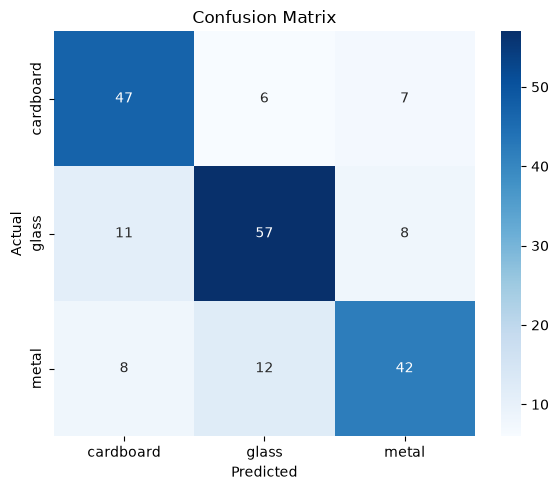

In [38]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("../images/training_plots/confusion_matrix.png")
plt.show()

In [39]:
# Classification report
print(classification_report(y_test, y_pred, target_names=CLASSES))

              precision    recall  f1-score   support

   cardboard       0.71      0.78      0.75        60
       glass       0.76      0.75      0.75        76
       metal       0.74      0.68      0.71        62

    accuracy                           0.74       198
   macro avg       0.74      0.74      0.74       198
weighted avg       0.74      0.74      0.74       198



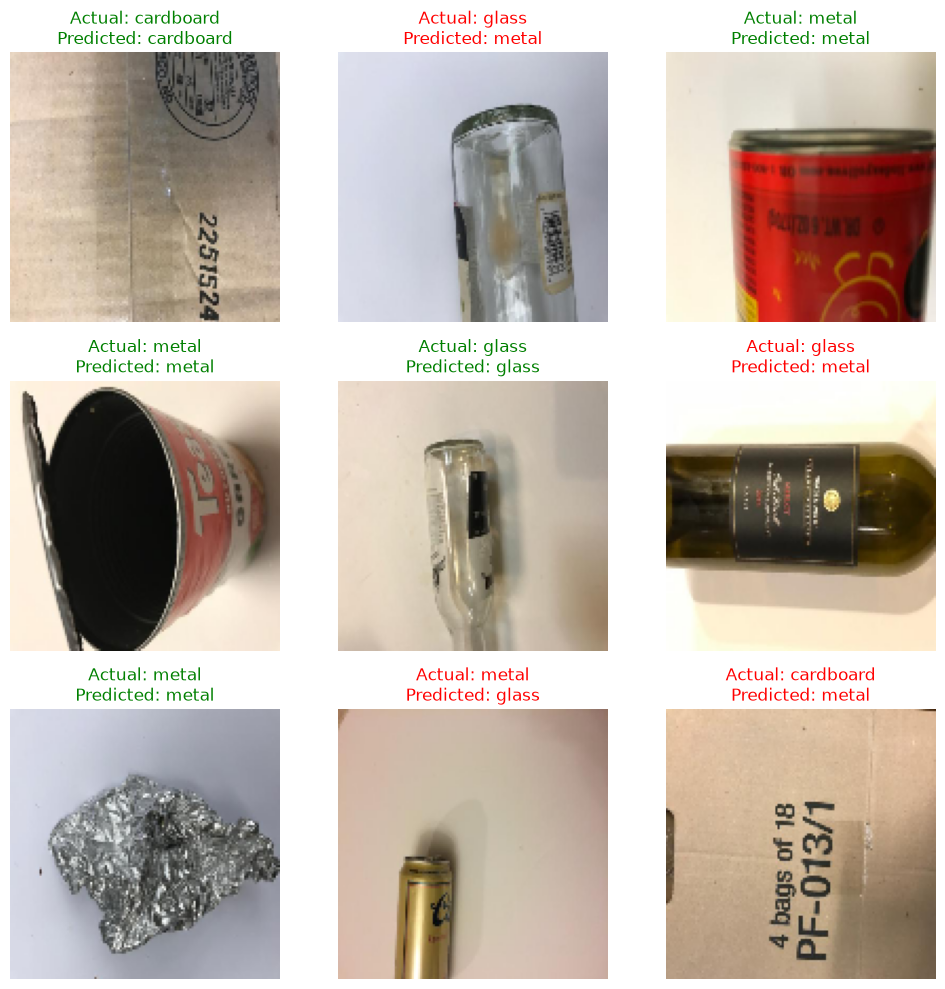

In [40]:
# Show sample predictions
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[i])
    actual = CLASSES[y_test[i]]
    predicted = CLASSES[y_pred[i]]
    color = "green" if actual == predicted else "red"
    plt.title(f"Actual: {actual}\nPredicted: {predicted}", color=color)
    plt.axis("off")
plt.tight_layout()
plt.savefig("../images/sample_predictions/sample_predictions.png")
plt.show()

In [1]:
pip install flask


   ---------------------------------------- 0/2 [werkzeug]
   ---------------------------------------- 0/2 [werkzeug]
   ---------------------------------------- 0/2 [werkzeug]
   ---------------------------------------- 0/2 [werkzeug]
   -------------------- ------------------- 1/2 [flask]
   ---------------------------------------- 2/2 [flask]

Note: you may need to restart the kernel to use updated packages.
